In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("bmw_global_sales_2018_2025.csv")

In [3]:
# df.shape

# df.head()

# df.isnull().sum()

# df.describe()

In [4]:
df = df.drop_duplicates()

In [5]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str))

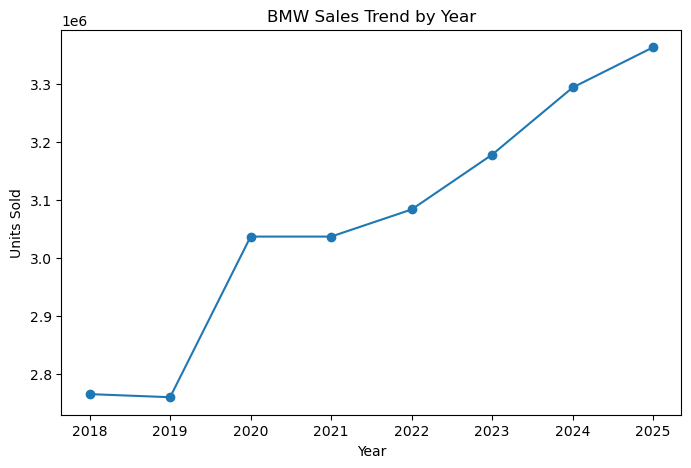

In [6]:
sales_year = df.groupby("Year")["Units_Sold"].sum()

plt.figure(figsize=(8,5))
# plt.legend()
sales_year.plot(kind="line", marker="o")
plt.title("BMW Sales Trend by Year")
plt.ylabel("Units Sold")
plt.show()

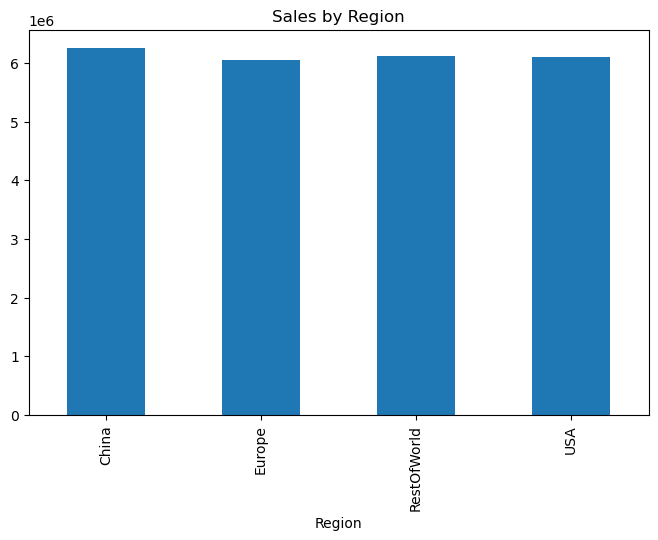

In [7]:
region_sales = df.groupby("Region")["Units_Sold"].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.show()

In [8]:
model_sales = df.groupby("Model")["Units_Sold"].sum().sort_values(ascending=False)

print(model_sales.head(10))

Model
iX          3136912
i4          3125687
X7          3112074
X5          3085134
5 Series    3052524
X3          3025861
3 Series    3006048
MINI        2971205
Name: Units_Sold, dtype: int64


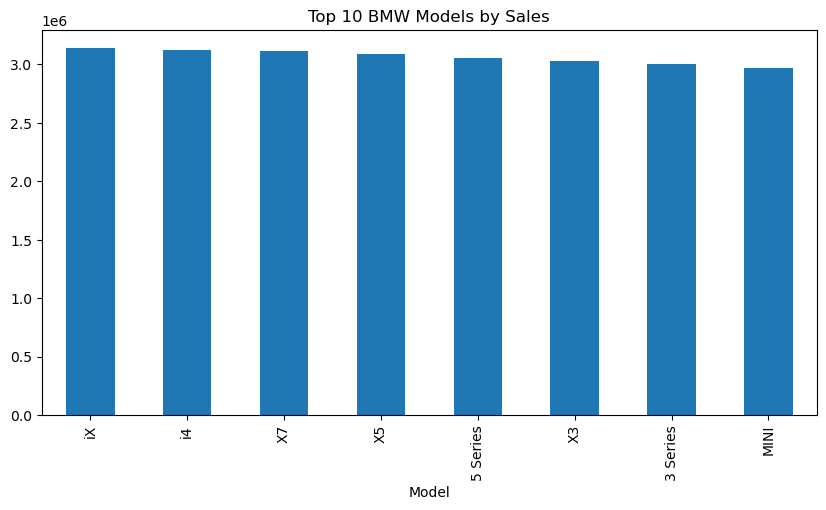

In [9]:
plt.figure(figsize=(10,5))
model_sales.head(10).plot(kind="bar")
plt.title("Top 10 BMW Models by Sales")
plt.show()

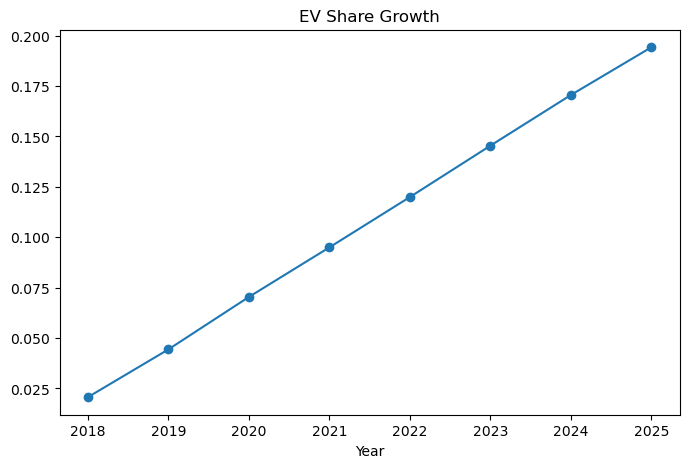

In [10]:
ev_trend = df.groupby("Year")["BEV_Share"].mean()

plt.figure(figsize=(8,5))
ev_trend.plot(kind="line", marker="o")
plt.title("EV Share Growth")
plt.show()

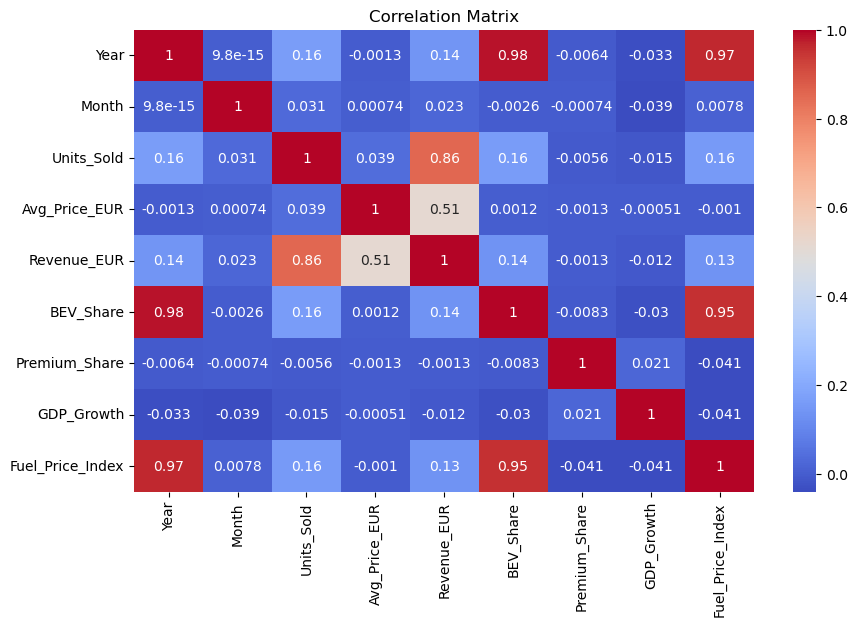

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

a = df[["Avg_Price_EUR","GDP_Growth","Fuel_Price_Index","BEV_Share"]]
b = df["Units_Sold"]

a_train,a_test,b_train,b_test = train_test_split(a,b,test_size=0.2,random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(a_train,b_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
pred = model.predict(a_test)

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(b_test,pred))
r2 = r2_score(b_test,pred)

print("RMSE:",rmse)
print("R2 Score:",r2)

RMSE: 3103.3511432834907
R2 Score: 0.031028492451074974


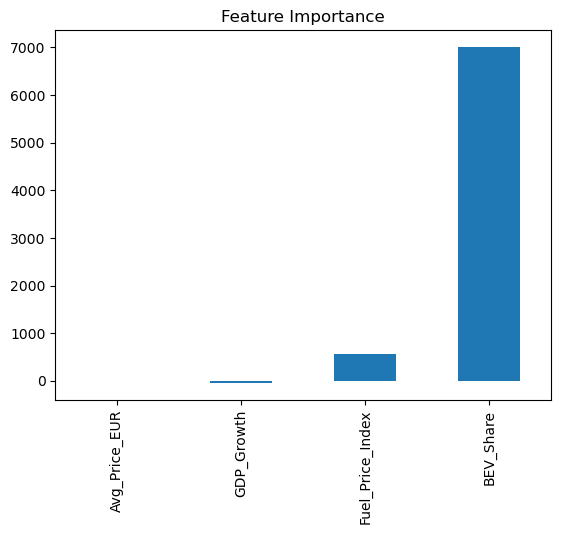

In [16]:
importance = pd.Series(model.coef_,index=a.columns)

importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()